<a href="https://colab.research.google.com/github/adishup/gen-ai-lab/blob/main/gen_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers torch

In [1]:
# ============================================================
# EXPERIMENT 1
# TEXT GENERATION USING PRETRAINED GPT-2
# ============================================================

import torch

from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel
)


# ============================================================
# 1. CHECK DEVICE
# ============================================================

if torch.cuda.is_available():

    device = torch.device("cuda")

    print("GPU Available")
    print("GPU:", torch.cuda.get_device_name(0))

else:

    device = torch.device("cpu")

    print("GPU not available. Using CPU.")


# ============================================================
# 2. LOAD GPT-2 TOKENIZER
# ============================================================

print("\nLoading GPT-2 tokenizer...")

tokenizer = GPT2Tokenizer.from_pretrained(
    "gpt2"
)

print("Tokenizer loaded successfully.")


# ============================================================
# 3. LOAD GPT-2 MODEL
# ============================================================

print("\nLoading GPT-2 model...")

model = GPT2LMHeadModel.from_pretrained(
    "gpt2"
)

model = model.to(device)

model.eval()

print("GPT-2 model loaded successfully.")


# ============================================================
# 4. DEFINE PROMPT
# ============================================================

prompt = "Artificial Intelligence is"

print("\nInput Prompt:")
print(prompt)


# ============================================================
# 5. TOKENIZE PROMPT
# ============================================================

input_ids = tokenizer.encode(
    prompt,
    return_tensors="pt"
)

input_ids = input_ids.to(device)


# ============================================================
# 6. GENERATE TEXT
# ============================================================

print("\nGenerating text...")

with torch.no_grad():

    output_ids = model.generate(
        input_ids,
        max_length=100,
        num_return_sequences=1,
        temperature=0.7,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id
    )


# ============================================================
# 7. DECODE GENERATED TEXT
# ============================================================

generated_text = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)


# ============================================================
# 8. DISPLAY RESULT
# ============================================================

print("\n" + "=" * 60)
print("GENERATED TEXT")
print("=" * 60)

print(generated_text)


# ============================================================
# 9. COMPLETION
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

GPU not available. Using CPU.

Loading GPT-2 tokenizer...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 model loaded successfully.

Input Prompt:
Artificial Intelligence is

Generating text...

GENERATED TEXT
Artificial Intelligence is now the most popular technology in the world. It's been used in the game, movies, and TV shows, and now it's being used in many other places.

I'm not going to go into much detail on how artificial intelligence is doing this, but what is interesting is the new techniques that are being applied. One of the things I was surprised by is that people are really starting to use it. Google, for example, is using artificial intelligence for their search

EXPERIMENT 1 COMPLETED SUCCESSFULLY


In [3]:
!pip install -q transformers torch

In [1]:
# ============================================================
# EXPERIMENT 2
# SENTIMENT ANALYSIS AND DOCUMENT CLASSIFICATION
# ============================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)


# ============================================================
# PART A — SENTIMENT ANALYSIS
# ============================================================

print("=" * 60)
print("PART A - SENTIMENT ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Select Device
# ------------------------------------------------------------

if torch.cuda.is_available():

    device = torch.device("cuda")

    print("GPU:", torch.cuda.get_device_name(0))

else:

    device = torch.device("cpu")

    print("Using CPU")


# ------------------------------------------------------------
# 2. Load Sentiment Model
# ------------------------------------------------------------

sentiment_model_name = (
    "distilbert-base-uncased-finetuned-sst-2-english"
)

print("\nLoading sentiment model...")

sentiment_tokenizer = AutoTokenizer.from_pretrained(
    sentiment_model_name
)

sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    sentiment_model_name
)

sentiment_model = sentiment_model.to(device)

sentiment_model.eval()

print("Sentiment model loaded successfully.")


# ------------------------------------------------------------
# 3. Input Text
# ------------------------------------------------------------

text = (
    "The Generative AI workshop was extremely "
    "informative and useful."
)


# ------------------------------------------------------------
# 4. Tokenize Text
# ------------------------------------------------------------

sentiment_inputs = sentiment_tokenizer(
    text,
    return_tensors="pt",
    truncation=True
)

sentiment_inputs = {
    key: value.to(device)
    for key, value in sentiment_inputs.items()
}


# ------------------------------------------------------------
# 5. Predict Sentiment
# ------------------------------------------------------------

with torch.no_grad():

    sentiment_output = sentiment_model(
        **sentiment_inputs
    )


# ------------------------------------------------------------
# 6. Calculate Probability
# ------------------------------------------------------------

probabilities = torch.softmax(
    sentiment_output.logits,
    dim=-1
)

predicted_class = torch.argmax(
    probabilities,
    dim=-1
).item()

confidence = probabilities[
    0,
    predicted_class
].item()


# ------------------------------------------------------------
# 7. Convert Label
# ------------------------------------------------------------

sentiment_labels = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

sentiment = sentiment_labels[
    predicted_class
]


# ------------------------------------------------------------
# 8. Display Sentiment
# ------------------------------------------------------------

print("\nInput:")
print(text)

print("\nSentiment:")
print(sentiment)

print("\nConfidence Score:")
print(round(confidence, 3))


# ============================================================
# PART B — DOCUMENT CLASSIFICATION
# ============================================================

print("\n")
print("=" * 60)
print("PART B - DOCUMENT CLASSIFICATION")
print("=" * 60)


# ------------------------------------------------------------
# 9. Load Zero-Shot Classification Model
# ------------------------------------------------------------

classification_model_name = (
    "facebook/bart-large-mnli"
)

print("\nLoading document classification model...")

classification_tokenizer = AutoTokenizer.from_pretrained(
    classification_model_name
)

classification_model = AutoModelForSequenceClassification.from_pretrained(
    classification_model_name
)

classification_model = classification_model.to(device)

classification_model.eval()

print("Classification model loaded successfully.")


# ------------------------------------------------------------
# 10. Input Document
# ------------------------------------------------------------

document = """
Artificial Intelligence and Machine Learning are transforming
industries through automation and intelligent decision-making.
"""


# ------------------------------------------------------------
# 11. Candidate Labels
# ------------------------------------------------------------

labels = [
    "Technology",
    "Sports",
    "Politics",
    "Entertainment"
]


# ------------------------------------------------------------
# 12. Calculate Scores for Each Label
# ------------------------------------------------------------

scores = []

for label in labels:

    hypothesis = (
        "This document is about " + label + "."
    )

    inputs = classification_tokenizer(
        document,
        hypothesis,
        return_tensors="pt",
        truncation=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        output = classification_model(
            **inputs
        )

    # BART-MNLI labels:
    # contradiction, neutral, entailment

    logits = output.logits[0]

    entailment_score = torch.softmax(
        logits,
        dim=-1
    )[2].item()

    scores.append(entailment_score)


# ------------------------------------------------------------
# 13. Find Best Category
# ------------------------------------------------------------

best_index = max(
    range(len(scores)),
    key=lambda i: scores[i]
)

predicted_category = labels[
    best_index
]

confidence = scores[
    best_index
]


# ------------------------------------------------------------
# 14. Display Classification
# ------------------------------------------------------------

print("\nDocument:")
print(document)

print("\nPredicted Category:")
print(predicted_category)

print("\nConfidence Score:")
print(round(confidence, 3))


# ============================================================
# 15. COMPLETION
# ============================================================

print("\n")
print("=" * 60)
print("EXPERIMENT 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

PART A - SENTIMENT ANALYSIS
Using CPU

Loading sentiment model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Classification model loaded successfully.

Document:

Artificial Intelligence and Machine Learning are transforming
industries through automation and intelligent decision-making.


Predicted Category:
Technology

Confidence Score:
0.401


EXPERIMENT 2 COMPLETED SUCCESSFULLY


In [1]:
!pip install -q transformers sentencepiece accelerate torch

In [2]:
# ============================================================
# EXPERIMENT 3
# TEXT SUMMARIZATION AND QUESTION ANSWERING
# ============================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForQuestionAnswering
)


# ============================================================
# 1. SELECT DEVICE
# ============================================================

if torch.cuda.is_available():

    device = torch.device("cuda")

    print("GPU Available")
    print("GPU:", torch.cuda.get_device_name(0))

else:

    device = torch.device("cpu")

    print("GPU not available. Using CPU.")


# ============================================================
# PART A — TEXT SUMMARIZATION
# ============================================================

print("\n" + "=" * 60)
print("PART A - TEXT SUMMARIZATION")
print("=" * 60)


# ------------------------------------------------------------
# 2. Load BART Tokenizer
# ------------------------------------------------------------

summarization_model_name = "facebook/bart-large-cnn"

print("\nLoading BART summarization model...")

summarization_tokenizer = AutoTokenizer.from_pretrained(
    summarization_model_name
)


# ------------------------------------------------------------
# 3. Load BART Model
# ------------------------------------------------------------

summarization_model = AutoModelForSeq2SeqLM.from_pretrained(
    summarization_model_name
)

summarization_model = summarization_model.to(device)

summarization_model.eval()

print("BART model loaded successfully.")


# ------------------------------------------------------------
# 4. Input Text
# ------------------------------------------------------------

text = """
Artificial Intelligence is transforming many industries by
enabling machines to perform tasks that normally require human
intelligence. It is widely used in healthcare, education,
manufacturing, finance, transportation, and cybersecurity.
AI systems can analyze large amounts of data, identify patterns,
make predictions, and support intelligent decision-making.
Generative AI is a branch of Artificial Intelligence that can
create new content such as text, images, audio, video, and
computer programs.
"""


# ------------------------------------------------------------
# 5. Tokenize Text
# ------------------------------------------------------------

inputs = summarization_tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)


# Move inputs to GPU/CPU
input_ids = inputs["input_ids"].to(device)
attention_mask = inputs["attention_mask"].to(device)


# ------------------------------------------------------------
# 6. Generate Summary
# ------------------------------------------------------------

print("\nGenerating summary...")

with torch.no_grad():

    summary_ids = summarization_model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_length=60,
        min_length=20,
        num_beams=4,
        do_sample=False
    )


# ------------------------------------------------------------
# 7. Decode Summary
# ------------------------------------------------------------

summary = summarization_tokenizer.decode(
    summary_ids[0],
    skip_special_tokens=True
)


# ------------------------------------------------------------
# 8. Display Summary
# ------------------------------------------------------------

print("\nOriginal Text:")
print(text)

print("\nSummary:")
print(summary)


# ============================================================
# PART B — QUESTION ANSWERING
# ============================================================

print("\n" + "=" * 60)
print("PART B - QUESTION ANSWERING")
print("=" * 60)


# ------------------------------------------------------------
# 9. Load Question Answering Model
# ------------------------------------------------------------

qa_model_name = "distilbert-base-cased-distilled-squad"

print("\nLoading Question Answering model...")

qa_tokenizer = AutoTokenizer.from_pretrained(
    qa_model_name
)

qa_model = AutoModelForQuestionAnswering.from_pretrained(
    qa_model_name
)

qa_model = qa_model.to(device)

qa_model.eval()

print("Question Answering model loaded successfully.")


# ------------------------------------------------------------
# 10. Context
# ------------------------------------------------------------

context = """
Generative Artificial Intelligence is a type of Artificial
Intelligence that can create new content such as text, images,
audio, video, and computer programs. Large Language Models are
commonly used for text generation, summarization, translation,
and question answering.
"""


# ------------------------------------------------------------
# 11. Question
# ------------------------------------------------------------

question = "What type of content can Generative AI create?"


# ------------------------------------------------------------
# 12. Tokenize Question and Context
# ------------------------------------------------------------

qa_inputs = qa_tokenizer(
    question,
    context,
    return_tensors="pt",
    truncation=True
)


# Move inputs to GPU/CPU
qa_inputs = {
    key: value.to(device)
    for key, value in qa_inputs.items()
}


# ------------------------------------------------------------
# 13. Predict Answer
# ------------------------------------------------------------

print("\nFinding answer...")

with torch.no_grad():

    qa_outputs = qa_model(
        **qa_inputs
    )


# ------------------------------------------------------------
# 14. Find Start and End Positions
# ------------------------------------------------------------

start_position = torch.argmax(
    qa_outputs.start_logits
)

end_position = torch.argmax(
    qa_outputs.end_logits
)


# Make sure end is not before start
if end_position < start_position:
    end_position = start_position


# ------------------------------------------------------------
# 15. Extract Answer Tokens
# ------------------------------------------------------------

answer_tokens = qa_inputs["input_ids"][
    0,
    start_position:end_position + 1
]


# ------------------------------------------------------------
# 16. Convert Tokens to Text
# ------------------------------------------------------------

answer = qa_tokenizer.decode(
    answer_tokens,
    skip_special_tokens=True
)


# ------------------------------------------------------------
# 17. Calculate Confidence Score
# ------------------------------------------------------------

start_score = torch.softmax(
    qa_outputs.start_logits,
    dim=-1
)[0, start_position]

end_score = torch.softmax(
    qa_outputs.end_logits,
    dim=-1
)[0, end_position]

confidence = (
    start_score * end_score
).item()


# ------------------------------------------------------------
# 18. Display Answer
# ------------------------------------------------------------

print("\nContext:")
print(context)

print("\nQuestion:")
print(question)

print("\nAnswer:")
print(answer)

print("\nConfidence Score:")
print(round(confidence, 3))


# ============================================================
# 19. COMPLETION
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT 3 COMPLETED SUCCESSFULLY")
print("=" * 60)

GPU not available. Using CPU.

PART A - TEXT SUMMARIZATION

Loading BART summarization model...


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

...

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  261MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Question Answering model loaded successfully.

Finding answer...

Context:

Generative Artificial Intelligence is a type of Artificial
Intelligence that can create new content such as text, images,
audio, video, and computer programs. Large Language Models are
commonly used for text generation, summarization, translation,
and question answering.


Question:
What type of content can Generative AI create?

Answer:
new content such as text, images, audio, video, and computer programs

Confidence Score:
0.267

EXPERIMENT 3 COMPLETED SUCCESSFULLY


In [5]:
!pip install -q transformers torch

ERROR: Operation cancelled by user


In [3]:
# ============================================================
# EXPERIMENT 4
# CONVERSATIONAL AI CHATBOT
# ============================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)


# ============================================================
# 1. Load DialoGPT Model
# ============================================================

model_name = "microsoft/DialoGPT-small"

print("Loading chatbot model...")

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForCausalLM.from_pretrained(
    model_name
)

print("Chatbot model loaded successfully.")


# ============================================================
# 2. Start Chatbot
# ============================================================

print("\n" + "=" * 60)
print("CONVERSATIONAL AI CHATBOT")
print("=" * 60)

print("\nType 'exit' to stop the chatbot.")


# Store conversation history
chat_history_ids = None


# ============================================================
# 3. Chat Loop
# ============================================================

while True:

    user_input = input("\nYou: ")


    # --------------------------------------------------------
    # Exit chatbot
    # --------------------------------------------------------

    if user_input.lower() == "exit":

        print("Chatbot: Goodbye!")

        break


    # --------------------------------------------------------
    # Convert user input into tokens
    # --------------------------------------------------------

    new_input_ids = tokenizer.encode(
        user_input + tokenizer.eos_token,
        return_tensors="pt"
    )


    # --------------------------------------------------------
    # Add previous conversation history
    # --------------------------------------------------------

    if chat_history_ids is not None:

        bot_input_ids = torch.cat(
            [
                chat_history_ids,
                new_input_ids
            ],
            dim=-1
        )

    else:

        bot_input_ids = new_input_ids


    # --------------------------------------------------------
    # Generate chatbot response
    # --------------------------------------------------------

    chat_history_ids = model.generate(
        bot_input_ids,
        max_length=1000,
        pad_token_id=tokenizer.eos_token_id
    )


    # --------------------------------------------------------
    # Extract only the new response
    # --------------------------------------------------------

    response_ids = chat_history_ids[
        :,
        bot_input_ids.shape[-1]:
    ]


    # --------------------------------------------------------
    # Convert response to text
    # --------------------------------------------------------

    response = tokenizer.decode(
        response_ids[0],
        skip_special_tokens=True
    )


    # --------------------------------------------------------
    # Display response
    # --------------------------------------------------------

    print("Chatbot:", response)

Loading chatbot model...


config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Chatbot model loaded successfully.

CONVERSATIONAL AI CHATBOT

Type 'exit' to stop the chatbot.

You: hello


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Chatbot: Hi

You: what is machine learning?
Chatbot: I'm a computer science major . I'm not sure what you're asking .

You: what is hardware?
Chatbot: I'm a computer science major . I'm not sure what you're asking .

You: exit
Chatbot: Goodbye!


In [3]:
!pip install -q -U transformers sentencepiece accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 70.2 MB/s eta 0:00:00


In [1]:
# ============================================================
# EXPERIMENT 5
# PROMPT ENGINEERING
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


# ============================================================
# 1. DEVICE
# ============================================================

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")


# ============================================================
# 2. LOAD FLAN-T5
# ============================================================

model_name = "google/flan-t5-base"

print("\nLoading FLAN-T5 model...")

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

model = model.to(device)
model.eval()

print("FLAN-T5 model loaded successfully.")


# ============================================================
# 3. GENERATION FUNCTION
# ============================================================

def generate_response(prompt, max_new_tokens=100):

    # Tokenize prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Move tensors to GPU/CPU
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # Generate response
    with torch.no_grad():

        output_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            do_sample=False,
            early_stopping=True,
            no_repeat_ngram_size=2
        )

    # Decode
    answer = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return answer.strip()


# ============================================================
# 4. CONTENT GENERATION
# ============================================================

content_prompt = """
Explain Generative AI to a first-year engineering student.

Use simple English.
Give exactly 4 sentences.
Mention two applications of Generative AI.
"""

content_result = generate_response(
    content_prompt,
    max_new_tokens=100
)

print("\n")
print("=" * 60)
print("1. CONTENT GENERATION")
print("=" * 60)

print(content_result)


# ============================================================
# 5. REASONING TASK
# ============================================================

reasoning_prompt = """
A college conducted a Generative AI workshop for 120 students.
85 students completed the workshop.

Calculate how many students did not complete the workshop.

Show the calculation and give the final answer.
"""

reasoning_result = generate_response(
    reasoning_prompt,
    max_new_tokens=80
)

print("\n")
print("=" * 60)
print("2. REASONING TASK")
print("=" * 60)

print(reasoning_result)


# ============================================================
# 6. EMAIL GENERATION
# ============================================================

email_prompt = """
Write a formal email to engineering students.

Subject: Generative AI Laboratory Session

The laboratory session is on Friday at 10:00 AM
in AI Laboratory 2.

Students must bring their laptops and complete
their Hugging Face account registration before
attending.

Write only the subject and email.
"""

email_result = generate_response(
    email_prompt,
    max_new_tokens=150
)

print("\n")
print("=" * 60)
print("3. EMAIL AUTOMATION")
print("=" * 60)

print(email_result)


# ============================================================
# 7. ACTION ITEM EXTRACTION
# ============================================================

action_prompt = """
Extract the action items from these meeting notes.

Meeting notes:

Adish will prepare the dataset by Wednesday.
Rahul will develop the machine learning model.
Priya will prepare the presentation.
The team will test the final system on Friday.

Give the result as:

Person - Task - Deadline
"""

action_result = generate_response(
    action_prompt,
    max_new_tokens=120
)

print("\n")
print("=" * 60)
print("4. ACTION ITEM EXTRACTION")
print("=" * 60)

print(action_result)


# ============================================================
# 8. COMPLETION
# ============================================================

print("\n")
print("=" * 60)
print("EXPERIMENT 5 COMPLETED SUCCESSFULLY")
print("=" * 60)

Using CPU

Loading FLAN-T5 model...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


FLAN-T5 model loaded successfully.


1. CONTENT GENERATION
Generative AI is a technology that uses artificial intelligence to predict the future of the world.


2. REASONING TASK
120 - 85 = 35 students did not complete the workshop. The final answer: 35.


3. EMAIL AUTOMATION
Generative AI Laboratory Session


4. ACTION ITEM EXTRACTION
Task


EXPERIMENT 5 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# EXPERIMENT 6
# BUILD RETRIEVAL-AUGMENTED GENERATION (RAG) SYSTEM
# USING VECTOR DATABASES
# ============================================================

# Install required libraries
!pip install -q -U sentence-transformers faiss-cpu transformers accelerate sentencepiece

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import faiss
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Libraries imported successfully!")


# ============================================================
# 1. CREATE KNOWLEDGE BASE
# ============================================================

documents = [
    """
    Generative Artificial Intelligence is a branch of Artificial Intelligence
    that creates new content such as text, images, audio, video and computer
    programs.
    """,

    """
    Large Language Models are transformer-based models trained on massive
    text datasets. They are used for text generation, summarization,
    translation, question answering and conversational AI.
    """,

    """
    Retrieval-Augmented Generation combines information retrieval with
    text generation. It retrieves relevant documents from an external
    knowledge base and gives them to a language model as context.
    """,

    """
    Vector databases store high-dimensional embeddings and perform
    similarity searches. Examples of vector databases include FAISS,
    ChromaDB, Pinecone, Weaviate and Milvus.
    """,

    """
    Prompt engineering is the process of designing clear instructions
    that guide a language model to produce accurate and useful responses.
    Common techniques include zero-shot, few-shot and role-based prompting.
    """,

    """
    Fine-tuning adapts a pretrained language model to a specific domain
    or task by training it further using a smaller domain-specific dataset.
    """
]

print("Knowledge base created successfully!")
print("Number of documents:", len(documents))


# ============================================================
# 2. LOAD SENTENCE TRANSFORMER EMBEDDING MODEL
# ============================================================

print("\nLoading embedding model...")

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")


# ============================================================
# 3. CONVERT DOCUMENTS INTO VECTOR EMBEDDINGS
# ============================================================

print("\nCreating document embeddings...")

document_embeddings = embedding_model.encode(
    documents,
    convert_to_numpy=True,
    show_progress_bar=True
)

# FAISS requires float32
document_embeddings = document_embeddings.astype(
    np.float32
)

# Normalize embeddings
faiss.normalize_L2(document_embeddings)

print("Document embeddings created successfully!")
print("Embedding shape:", document_embeddings.shape)


# ============================================================
# 4. CREATE FAISS VECTOR DATABASE
# ============================================================

embedding_dimension = document_embeddings.shape[1]

vector_database = faiss.IndexFlatIP(
    embedding_dimension
)

# Add embeddings to FAISS
vector_database.add(
    document_embeddings
)

print("\nFAISS vector database created successfully!")
print("Number of vectors:", vector_database.ntotal)


# ============================================================
# 5. LOAD FLAN-T5 MODEL
# ============================================================

print("\nLoading FLAN-T5 model...")

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

generator_model = generator_model.to(device)

print("FLAN-T5 model loaded successfully!")
print("Device:", device)


# ============================================================
# 6. RETRIEVAL FUNCTION
# ============================================================

def retrieve_documents(query, top_k=2):

    # Convert user query into embedding
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    query_embedding = query_embedding.astype(
        np.float32
    )

    # Normalize query embedding
    faiss.normalize_L2(query_embedding)

    # Search FAISS database
    similarity_scores, document_indices = (
        vector_database.search(
            query_embedding,
            top_k
        )
    )

    retrieved_documents = []

    for index, score in zip(
        document_indices[0],
        similarity_scores[0]
    ):

        retrieved_documents.append({
            "document": documents[index].strip(),
            "score": float(score)
        })

    return retrieved_documents


# ============================================================
# 7. ANSWER GENERATION FUNCTION
# ============================================================

def generate_answer(query, retrieved_documents):

    # Combine retrieved documents
    context = "\n\n".join(
        item["document"]
        for item in retrieved_documents
    )

    # RAG prompt
    prompt = f"""
Answer the question using only the information provided
in the context.

Context:
{context}

Question:
{query}

Instructions:
1. Give a clear and concise answer.
2. Do not add information that is not present in the context.
3. If the answer is unavailable, say:
The answer is not available in the knowledge base.

Answer:
"""

    # Tokenize
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Move tensors to GPU/CPU
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Generate answer
    with torch.no_grad():

        outputs = generator_model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False
        )

    # Decode
    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer


# ============================================================
# 8. RUN RAG SYSTEM
# ============================================================

print("\n")
print("=" * 60)
print("       RETRIEVAL-AUGMENTED GENERATION SYSTEM")
print("=" * 60)

user_query = input(
    "\nEnter your question: "
)


# ============================================================
# 9. RETRIEVE RELEVANT DOCUMENTS
# ============================================================

retrieved_results = retrieve_documents(
    user_query,
    top_k=2
)


# ============================================================
# 10. GENERATE ANSWER
# ============================================================

answer = generate_answer(
    user_query,
    retrieved_results
)


# ============================================================
# 11. DISPLAY RETRIEVED DOCUMENTS
# ============================================================

print("\n")
print("=" * 60)
print("              RETRIEVED DOCUMENTS")
print("=" * 60)

for number, item in enumerate(
    retrieved_results,
    start=1
):

    print(f"\nDocument {number}")
    print("-" * 60)

    print(item["document"])

    print(
        "\nSimilarity Score:",
        f"{item['score']:.4f}"
    )


# ============================================================
# 12. DISPLAY GENERATED ANSWER
# ============================================================

print("\n")
print("=" * 60)
print("                GENERATED ANSWER")
print("=" * 60)

print(answer)


# ============================================================
# END
# ============================================================

print("\n")
print("=" * 60)
print("RAG SYSTEM EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 37.9 MB/s eta 0:00:00
Libraries imported successfully!
Knowledge base created successfully!
Number of documents: 6

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded successfully!

Creating document embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Document embeddings created successfully!
Embedding shape: (6, 384)

FAISS vector database created successfully!
Number of vectors: 6

Loading FLAN-T5 model...


...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

FLAN-T5 model loaded successfully!
Device: cpu


       RETRIEVAL-AUGMENTED GENERATION SYSTEM

Enter your question: what is ai


              RETRIEVED DOCUMENTS

Document 1
------------------------------------------------------------
Generative Artificial Intelligence is a branch of Artificial Intelligence
    that creates new content such as text, images, audio, video and computer
    programs.

Similarity Score: 0.5319

Document 2
------------------------------------------------------------
Large Language Models are transformer-based models trained on massive
    text datasets. They are used for text generation, summarization,
    translation, question answering and conversational AI.

Similarity Score: 0.2509


                GENERATED ANSWER
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .


RAG SYSTEM EXECUTION COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# EXPERIMENT 7
# Fine-tune Pre-trained Language Model
# Domain-Specific Text Classification
# ============================================================

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

# ============================================================
# 1. Create Domain-Specific Dataset
# ============================================================

data = {
    "text": [
        "The transformer model achieved excellent accuracy.",
        "Large Language Models are revolutionizing AI.",
        "The football team won the championship.",
        "The cricket match was exciting.",
        "Neural networks are widely used in deep learning.",
        "The player scored a brilliant goal.",
        "Machine learning improves decision making.",
        "The tennis tournament starts tomorrow."
    ],

    # 0 = Sports
    # 1 = Technology
    "label": [
        1,
        1,
        0,
        0,
        1,
        0,
        1,
        0
    ]
}

# Convert dictionary to Hugging Face Dataset
dataset = Dataset.from_dict(data)

print("Dataset created successfully.")
print(dataset)


# ============================================================
# 2. Load Pre-trained BERT Tokenizer
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

print("\nTokenizer loaded successfully.")


# ============================================================
# 3. Tokenize Dataset
# ============================================================

def tokenize_function(example):

    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )


dataset = dataset.map(
    tokenize_function
)

print("Dataset tokenized successfully.")


# ============================================================
# 4. Remove Original Text Column
# ============================================================

dataset = dataset.remove_columns(
    ["text"]
)

print("Text column removed.")


# ============================================================
# 5. Load Pre-trained BERT Model
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT model loaded successfully.")


# ============================================================
# 6. Training Configuration
# ============================================================

training_args = TrainingArguments(
    output_dir="./fine_tuned_model",

    # Batch size
    per_device_train_batch_size=2,

    # Number of epochs
    num_train_epochs=3,

    # Logging
    logging_steps=1,

    # Do not save checkpoints during training
    save_strategy="no",

    # Disable external logging
    report_to="none",

    # Disable evaluation
    eval_strategy="no"
)


# ============================================================
# 7. Create Trainer
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset
)


# ============================================================
# 8. Fine-Tune Model
# ============================================================

print("\n")
print("=" * 60)
print("STARTING MODEL TRAINING")
print("=" * 60)

trainer.train()

print("\nTraining completed successfully.")


# ============================================================
# 9. Save Fine-Tuned Model
# ============================================================

model_path = "./fine_tuned_model"

trainer.save_model(model_path)

tokenizer.save_pretrained(
    model_path
)

print("\nFine-tuned model saved to:")
print(model_path)


# ============================================================
# 10. Load Fine-Tuned Model
# ============================================================

classifier = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path
)

print("\nFine-tuned model loaded successfully.")


# ============================================================
# 11. Test New Text
# ============================================================

test_text = (
    "Generative AI models improve intelligent automation."
)

result = classifier(
    test_text
)


# ============================================================
# 12. Define Class Labels
# ============================================================

labels = {
    "LABEL_0": "Sports",
    "LABEL_1": "Technology"
}


predicted_label = labels[
    result[0]["label"]
]

confidence = result[0]["score"]


# ============================================================
# 13. Display Prediction
# ============================================================

print("\n")
print("=" * 60)
print("PREDICTION")
print("=" * 60)

print("\nInput:")
print(test_text)

print("\nPredicted Class:")
print(predicted_label)

print("\nConfidence Score:")
print(round(confidence, 3))

Dataset created successfully.
Dataset({
    features: ['text', 'label'],
    num_rows: 8
})

Tokenizer loaded successfully.


Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Dataset tokenized successfully.
Text column removed.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


Training completed successfully.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuned model saved to:
./fine_tuned_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Fine-tuned model loaded successfully.


PREDICTION

Input:
Generative AI models improve intelligent automation.

Predicted Class:
Technology

Confidence Score:
0.752


In [5]:
# Install compatible versions for Experiment 8
!pip install -q transformers==4.46.3 tokenizers==0.20.3 sentencepiece==0.2.0 accelerate==0.34.2

print("Installation completed.")

Installation completed.


In [1]:
import transformers
import tokenizers

print("Transformers version:", transformers.__version__)
print("Tokenizers version:", tokenizers.__version__)

Transformers version: 4.46.3
Tokenizers version: 0.20.3


In [2]:
# ============================================================
# EXPERIMENT 8
# AI-POWERED CODE GENERATION AND DEBUGGING ASSISTANT
# ============================================================

import torch

from transformers import (
    RobertaTokenizer,
    T5ForConditionalGeneration
)

# ------------------------------------------------------------
# 1. Select Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. Load CodeT5
# ------------------------------------------------------------

model_name = "Salesforce/codet5-base"

print("\nLoading CodeT5 tokenizer...")

tokenizer = RobertaTokenizer.from_pretrained(
    model_name
)

print("Tokenizer loaded successfully.")

print("\nLoading CodeT5 model...")

model = T5ForConditionalGeneration.from_pretrained(
    model_name
)

model = model.to(device)

print("CodeT5 model loaded successfully.")


# ------------------------------------------------------------
# 3. Generate Response Function
# ------------------------------------------------------------

def generate_response(prompt, max_tokens=200):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():

        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_tokens,
            do_sample=False
        )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response


# ------------------------------------------------------------
# 4. CODE GENERATION
# ------------------------------------------------------------

code_task = """
Write a Python program to calculate the factorial
of a number using a recursive function.

Requirements:
1. Accept a number from the user.
2. Use recursion.
3. Display the factorial.
4. Handle negative input.
"""

generation_prompt = (
    "Generate Python code for the following task:\n\n"
    + code_task
)

print("\nGenerating Python code...")

generated_code = generate_response(
    generation_prompt
)


# ------------------------------------------------------------
# 5. DEBUGGING
# ------------------------------------------------------------

faulty_code = """
def calculate_average(numbers):
    total = sum(numbers)
    average = total / len(number)
    return average

values = [10, 20, 30, 40]

print("Average:", calculate_average(values))
"""

debugging_prompt = """
Find and correct the error in the following Python code.

Code:

""" + faulty_code + """

Identify the error and provide the corrected code.
"""

print("Analyzing faulty code...")

debugging_result = generate_response(
    debugging_prompt
)


# ------------------------------------------------------------
# 6. Display Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AI-POWERED CODE GENERATION AND DEBUGGING ASSISTANT")
print("=" * 60)

print("\n1. GENERATED CODE")
print("-" * 60)

print(generated_code)

print("\n2. DEBUGGING RESULT")
print("-" * 60)

print(debugging_result)

Device: cpu

Loading CodeT5 tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

CodeT5 model loaded successfully.

Generating Python code...


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Analyzing faulty code...

AI-POWERED CODE GENERATION AND DEBUGGING ASSISTANT

1. GENERATED CODE
------------------------------------------------------------
a number from the user.anumber from the user.
5.thefactorial.
6. Display thefactorial.
7. Handleinput.a number from the user.a number from the user.a number from the user.a number from the user.
6.a number from the user.
7.anumber.a number.a number.a number.

2. DEBUGGING RESULT
------------------------------------------------------------
()))))) ))) )))))))) ))) )) )) )) )) )) )) )) ) ))


In [3]:
!pip install -q diffusers transformers accelerate torch pillow matplotlib


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU Available
GPU: Tesla T4

Loading Stable Diffusion model...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully.

Prompt:

A futuristic smart city with flying cars,
green buildings, robots assisting people,
highly detailed, realistic, 4K quality.


Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]

Image generated successfully.
Image saved as: generated_image.png


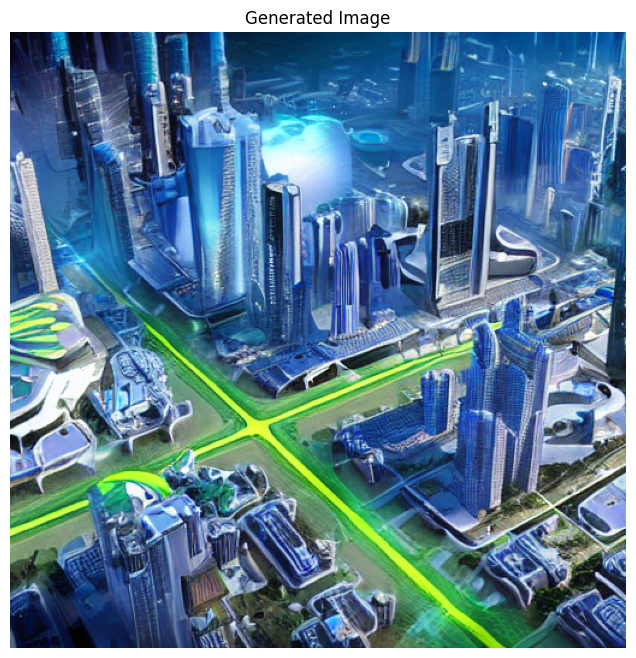

In [4]:
# ============================================================
# EXPERIMENT 9
# IMAGE GENERATION USING DIFFUSION MODELS
# ============================================================

import torch
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline


# ------------------------------------------------------------
# 1. Check GPU / CPU
# ------------------------------------------------------------

if torch.cuda.is_available():
    device = "cuda"
    print("GPU Available")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("GPU not available. Using CPU.")


# ------------------------------------------------------------
# 2. Load Stable Diffusion Model
# ------------------------------------------------------------

model_id = "runwayml/stable-diffusion-v1-5"

print("\nLoading Stable Diffusion model...")

if device == "cuda":
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    )
else:
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float32
    )

# Move model to GPU or CPU
pipe = pipe.to(device)

print("Model loaded successfully.")


# ------------------------------------------------------------
# 3. Define Text Prompt
# ------------------------------------------------------------

prompt = """
A futuristic smart city with flying cars,
green buildings, robots assisting people,
highly detailed, realistic, 4K quality.
"""

print("\nPrompt:")
print(prompt)


# ------------------------------------------------------------
# 4. Generate Image
# ------------------------------------------------------------

print("\nGenerating image...")

image = pipe(
    prompt
).images[0]

print("Image generated successfully.")


# ------------------------------------------------------------
# 5. Save Image
# ------------------------------------------------------------

image_path = "generated_image.png"

image.save(image_path)

print("Image saved as:", image_path)


# ------------------------------------------------------------
# 6. Display Image
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.axis("off")

plt.title("Generated Image")

plt.show()

In [5]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [6]:
!pip install -q transformers torch pillow matplotlib sentencepiece

GPU Available
GPU: Tesla T4

Loading BLIP model...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

BLIP model loaded successfully.

Upload an image for analysis:


Saving munnar images.png to munnar images.png


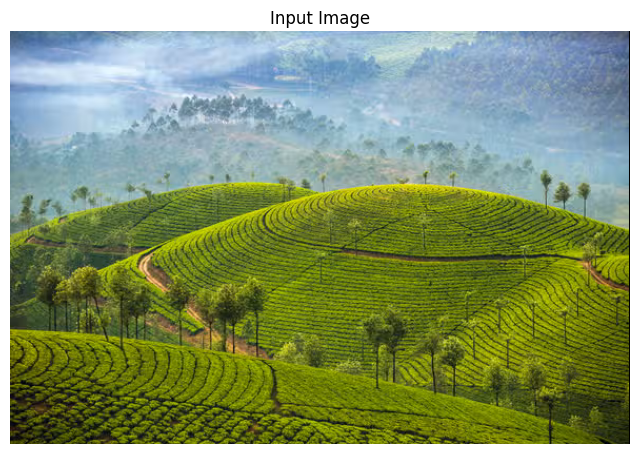


Enter a question about the uploaded image: what kind of place is this image shows ?

Generating answer...


MULTIMODAL AI RESULT

Question:
what kind of place is this image shows ?

Answer:
farm


In [7]:
# ============================================================
# EXPERIMENT 10
# MULTIMODAL AI APPLICATION
# IMAGE + TEXT QUESTION ANSWERING
# ============================================================

# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

import torch
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

from transformers import (
    BlipProcessor,
    BlipForQuestionAnswering
)


# ------------------------------------------------------------
# 2. Check Device
# ------------------------------------------------------------

if torch.cuda.is_available():
    device = "cuda"
    print("GPU Available")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("GPU not available. Using CPU.")


# ------------------------------------------------------------
# 3. Load BLIP Model
# ------------------------------------------------------------

model_name = "Salesforce/blip-vqa-base"

print("\nLoading BLIP model...")

processor = BlipProcessor.from_pretrained(
    model_name
)

model = BlipForQuestionAnswering.from_pretrained(
    model_name
)

model = model.to(device)

print("BLIP model loaded successfully.")


# ------------------------------------------------------------
# 4. Upload Image
# ------------------------------------------------------------

print("\nUpload an image for analysis:")

uploaded_files = files.upload()


# Get uploaded image filename
image_path = next(
    iter(uploaded_files)
)


# ------------------------------------------------------------
# 5. Open Image
# ------------------------------------------------------------

image = Image.open(
    image_path
).convert("RGB")


# ------------------------------------------------------------
# 6. Display Uploaded Image
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.imshow(image)

plt.axis("off")

plt.title("Input Image")

plt.show()


# ------------------------------------------------------------
# 7. Get Question from User
# ------------------------------------------------------------

question = input(
    "\nEnter a question about the uploaded image: "
)


# ------------------------------------------------------------
# 8. Process Image + Question
# ------------------------------------------------------------

inputs = processor(
    images=image,
    text=question,
    return_tensors="pt"
)


# ------------------------------------------------------------
# 9. Move Inputs to GPU / CPU
# ------------------------------------------------------------

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


# ------------------------------------------------------------
# 10. Generate Answer
# ------------------------------------------------------------

print("\nGenerating answer...")

with torch.no_grad():

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=30
    )


# ------------------------------------------------------------
# 11. Decode Answer
# ------------------------------------------------------------

answer = processor.decode(
    generated_ids[0],
    skip_special_tokens=True
)


# ------------------------------------------------------------
# 12. Display Result
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("MULTIMODAL AI RESULT")
print("=" * 60)

print("\nQuestion:")
print(question)

print("\nAnswer:")
print(answer)